# 🏷️ Notebook 02 — Labeling & Preprocessing
## Bagian 1: Labeling Strategi Sentimen + Bagian 2: Preprocessing Pipeline

**Tujuan:**
1. Labeling ternary: Rating 1-2 → Negatif, 3 → Netral, 4-5 → Positif
2. Full NLP preprocessing pipeline untuk Bahasa Indonesia
3. Validasi hasil preprocessing

## Setup & Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import (
    add_sentiment_labels,
    preprocess_dataframe,
    show_preprocessing_examples
)
from src.evaluator import plot_wordcloud

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)

## Load Dataset Prepared

In [2]:
df = pd.read_csv('../data/processed/reviews_prepared.csv')
print(f"📊 Dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"📋 Kolom: {list(df.columns)}")

📊 Dataset: 609 baris, 11 kolom
📋 Kolom: ['user_name', 'rating', 'date', 'review_text', 'likes', 'app_version', 'word_count', 'char_count', 'year_month', 'is_duplicate', 'sentiment']


## Bagian 1 — Labeling Strategi Sentimen (1.1)

Skema labeling **TERNARY**:
- Rating 1-2 → **Negatif**
- Rating 3 → **Netral**
- Rating 4-5 → **Positif**

**PENTING:** Rating 3 TIDAK di-drop. Tetap masuk sebagai kelas Netral.

In [3]:
# Apply labeling
df = add_sentiment_labels(df)


🏷️  Labeling Ternary:
   Negatif   :   203 (33.3%)
   Netral    :   203 (33.3%)
   Positif   :   203 (33.3%)

   Rasio imbalance (max/min): 1.0x
   ⚠️  Kelas Netral sangat minoritas (203 ulasan)


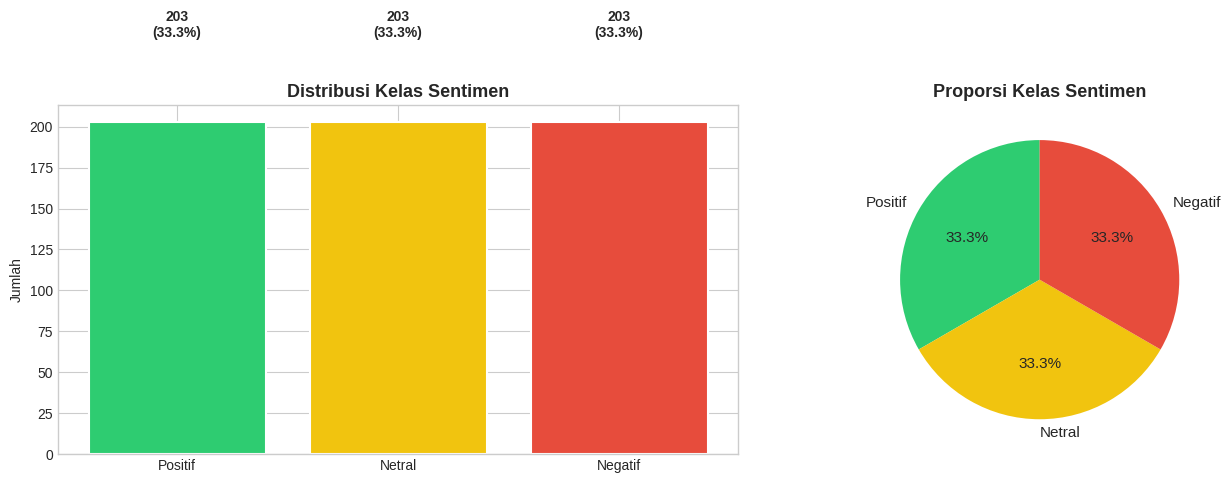

In [4]:
# Visualisasi distribusi sentimen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_sentiment = {'Negatif': '#E74C3C', 'Netral': '#F1C40F', 'Positif': '#2ECC71'}
sentiment_counts = df['sentiment'].value_counts()
bars = axes[0].bar(sentiment_counts.index, sentiment_counts.values,
                   color=[colors_sentiment[s] for s in sentiment_counts.index],
                   edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, sentiment_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                 f'{count:,}\n({count/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribusi Kelas Sentimen', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')

# Pie chart
axes[1].pie(sentiment_counts.values, labels=sentiment_counts.index,
            colors=[colors_sentiment[s] for s in sentiment_counts.index],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporsi Kelas Sentimen', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/eda/sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Analisis tantangan kelas Netral
print("\n⚠️  Analisis Tantangan Kelas Netral:")
print("=" * 50)
netral_reviews = df[df['sentiment'] == 'Netral']['review_text']
print(f"   Total review Netral: {len(netral_reviews)}")
print(f"   Proporsi: {len(netral_reviews)/len(df)*100:.1f}%")
print(f"\n   Contoh review Netral:")
for text in netral_reviews.head(5):
    print(f"   • {str(text)[:100]}")


⚠️  Analisis Tantangan Kelas Netral:
   Total review Netral: 203
   Proporsi: 33.3%

   Contoh review Netral:
   • Nunggu kode verifikasi ga msk2 pdh udh dicoba berkali2 tp ga da emai yg msk udh d cek d folder laen 
   • Mau daftar tapi tidak bisa
   • Alangkah baiknya lapor SPT bisa diaplikasi ini juga
   • I think the feature is still incomplete compared to the web version
   • Untuk M-Pajak belum support npwp 16 digit ya? Saya mau buat efin harus isi npwp 15 digit😔,kalo sudah


## Bagian 2 — Preprocessing Pipeline (2.1)

Pipeline preprocessing:
1. Case folding
2. Noise removal (HTML, URL, mention, hashtag, angka)
3. Emoji removal
4. Normalisasi slang/singkatan Indonesia
5. Stopword removal (dengan preservasi kata negasi)
6. Stemming (Sastrawi)
7. Tokenisasi

In [6]:
# Apply full preprocessing pipeline
print("\n🔄 Menjalankan Preprocessing Pipeline...")
print("   ⚠️  Proses ini mungkin memakan waktu beberapa menit (stemming)")
print("      karena Sastrawi stemmer memproses setiap kata secara individual.\n")

df = preprocess_dataframe(
    df,
    text_col='review_text',
    remove_stopwords=True,
    apply_stemming=True
)


🔄 Menjalankan Preprocessing Pipeline...
   ⚠️  Proses ini mungkin memakan waktu beberapa menit (stemming)
      karena Sastrawi stemmer memproses setiap kata secara individual.

🔄 Preprocessing 609 teks...
   Stopword removal: ✅
   Stemming: ✅
   ✅ Selesai!
   📊 Rata-rata token per review: 6.8
   ⚠️  Review kosong setelah preprocessing: 19


In [7]:
# Tampilkan contoh preprocessing
show_preprocessing_examples(df, n=10)


📋 Contoh Preprocessing (Before → After):

  ⭐ Rating 1 | Sentimen: Negatif
  📝 Before: gak ada solusi, bukanya mempermudah malah mempersulit
  ✅ After : tidak solusi buka mudah sulit

  ⭐ Rating 4 | Sentimen: Positif
  📝 Before: kenapa mau daftar pajak gini amat dulu pakai djp online mudah yang penting punya
  ✅ After : daftar pajak pakai djp online mudah efin kesini tidak ubah data email nomor hand

  ⭐ Rating 4 | Sentimen: Positif
  📝 Before: Halo ka kenapa halaman wep tidak ada tampil tombol kirim di adroid versi xiomi h
  ✅ After : halo ka halaman wep tidak tampil tombol kirim adroid versi xiomi hyper os ka

  ⭐ Rating 5 | Sentimen: Positif
  📝 Before: Hemat sangat
  ✅ After : hemat

  ⭐ Rating 5 | Sentimen: Positif
  📝 Before: Ok
  ✅ After : ok

  ⭐ Rating 3 | Sentimen: Netral
  📝 Before: Mau pasang listrik di Indonesia harus ada nidi , slo, siup dan nib, buat siup da
  ✅ After : pasang listrik indonesia nidi slo siup nib siup nib nomor npwp gilir nomor npwp 

  ⭐ Rating 1 | Sent

In [8]:
# Statistik setelah preprocessing
print("\n📊 Statistik Setelah Preprocessing:")
print(f"   Total baris: {len(df)}")
print(f"   Review kosong: {(df['review_clean'] == '').sum()}")
print(f"   Rata-rata token: {df['review_tokens'].apply(len).mean():.1f}")
print(f"   Median token: {df['review_tokens'].apply(len).median():.0f}")


📊 Statistik Setelah Preprocessing:
   Total baris: 609
   Review kosong: 19
   Rata-rata token: 6.8
   Median token: 4


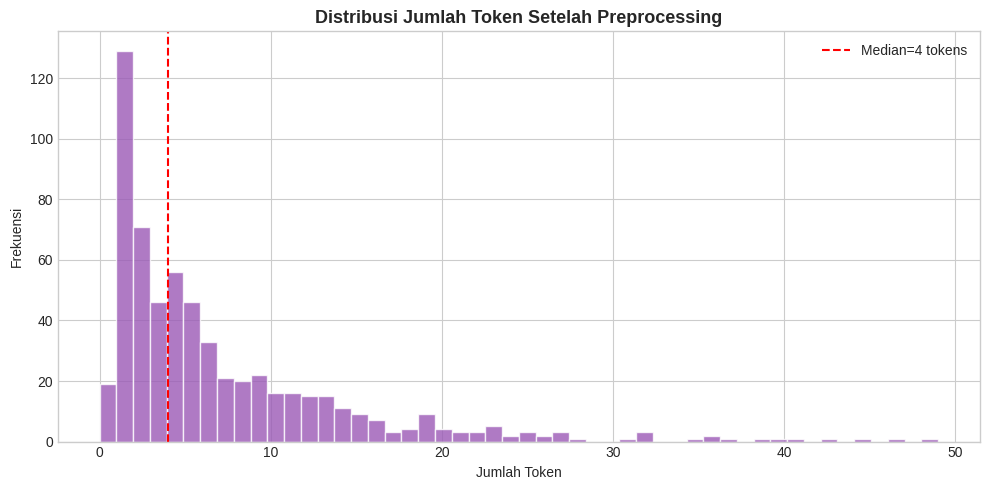

In [9]:
# Distribusi panjang teks setelah preprocessing
fig, ax = plt.subplots(figsize=(10, 5))
token_lengths = df['review_tokens'].apply(len)
ax.hist(token_lengths, bins=50, color='#9B59B6', edgecolor='white', alpha=0.8)
ax.axvline(token_lengths.median(), color='red', linestyle='--',
           label=f'Median={token_lengths.median():.0f} tokens')
ax.set_xlabel('Jumlah Token')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Jumlah Token Setelah Preprocessing', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/eda/token_distribution_after_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()

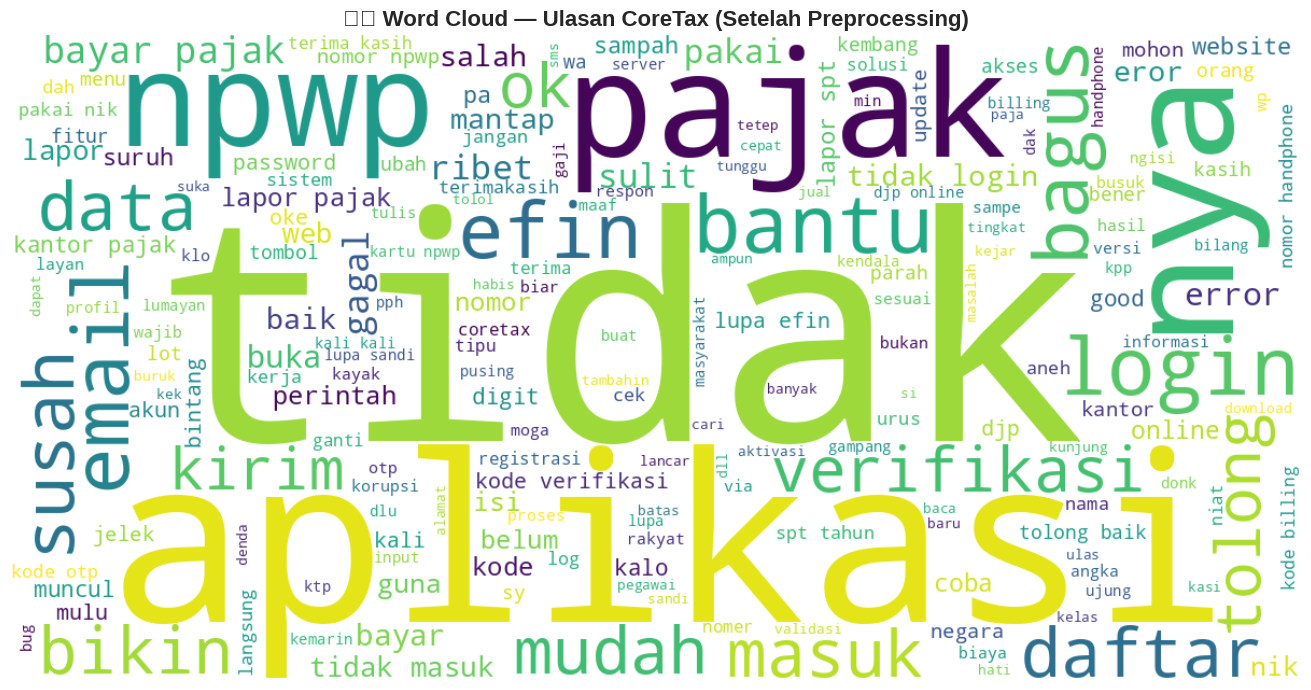

In [10]:
# Word cloud setelah preprocessing
plot_wordcloud(
    df['review_clean'].tolist(),
    title='☁️ Word Cloud — Ulasan CoreTax (Setelah Preprocessing)',
    save_path='../results/figures/eda/wordcloud_preprocessed.png'
)

In [11]:
# Validasi manual: 50 sampel
print("\n📋 Validasi Manual — 50 Sampel Acak:")
print("=" * 80)
sample = df.sample(n=50, random_state=42)
for idx, row in sample.head(10).iterrows():
    print(f"\n  ⭐ {row['rating']} | {row['sentiment']}")
    print(f"  RAW  : {str(row['review_text'])[:80]}")
    print(f"  CLEAN: {str(row['review_clean'])[:80]}")


📋 Validasi Manual — 50 Sampel Acak:

  ⭐ 1 | Negatif
  RAW  : gak ada solusi, bukanya mempermudah malah mempersulit
  CLEAN: tidak solusi buka mudah sulit

  ⭐ 4 | Positif
  RAW  : kenapa mau daftar pajak gini amat dulu pakai djp online mudah yang penting punya
  CLEAN: daftar pajak pakai djp online mudah efin kesini tidak ubah data email nomor hand

  ⭐ 4 | Positif
  RAW  : Halo ka kenapa halaman wep tidak ada tampil tombol kirim di adroid versi xiomi h
  CLEAN: halo ka halaman wep tidak tampil tombol kirim adroid versi xiomi hyper os ka

  ⭐ 5 | Positif
  RAW  : Hemat sangat
  CLEAN: hemat

  ⭐ 5 | Positif
  RAW  : Ok
  CLEAN: ok

  ⭐ 3 | Netral
  RAW  : Mau pasang listrik di Indonesia harus ada nidi , slo, siup dan nib, buat siup da
  CLEAN: pasang listrik indonesia nidi slo siup nib siup nib nomor npwp gilir nomor npwp 

  ⭐ 1 | Negatif
  RAW  : kacau
  CLEAN: kacau

  ⭐ 1 | Negatif
  RAW  : sangat lambannnnn
  CLEAN: lambannnnn

  ⭐ 5 | Positif
  RAW  : congratulations🎉🥳👏
  CLEAN

In [12]:
# Simpan dataset final
output_path = '../data/processed/reviews_prepared.csv'
df.to_csv(output_path, index=False)
print(f"\n💾 Dataset final tersimpan: {output_path}")
print(f"   Kolom baru: sentiment, sentiment_encoded, review_clean, review_tokens")
print(f"   Total baris: {len(df)}")


💾 Dataset final tersimpan: ../data/processed/reviews_prepared.csv
   Kolom baru: sentiment, sentiment_encoded, review_clean, review_tokens
   Total baris: 609


## Ringkasan

| Tahap | Detail |
|-------|--------|
| Labeling | Ternary: Negatif (1-2), Netral (3), Positif (4-5) |
| Preprocessing | Case fold → Noise removal → Slang norm → Stopword → Stemming |
| Output | `data/processed/reviews_prepared.csv` dengan kolom `review_clean` dan `sentiment` |

In [13]:
print("\n✅ Bagian 1 & 2 selesai! Dataset siap untuk Feature Extraction.")


✅ Bagian 1 & 2 selesai! Dataset siap untuk Feature Extraction.
